In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from GG4 import Brain

sys.path.insert(0, str((Path(".").resolve().parent / "shared")))
sys.path.insert(0, str(Path(".").resolve()))

from bode import (
    NOTEBOOK_GITHUB_URL,
    compute_analytic_bode,
    compute_empirical_bode,
    make_bode_figure,
)
from constants import (
    CAPTIONS_PATH,
    ESTIMATOR_PATHS,
    FIGURES_PATH,
    N_FFT,
    N_MARKOV,
    RANDOM_SEED,
)
from era_utils import collect_markov_parameters
from pgf_utils import (
    configure_pgf,
    configure_screen,
    figure_inches,
    save_caption,
    save_pgf,
)
from system_estimate import SystemEstimate

In [2]:
# ── experiment constants ───────────────────────────────────────────────────────
DISPLAY_OUTPUT = 0     # output (neuron) index to feature in Bode panels

In [3]:
# ── derived: Brain input dimension and estimator matrices ─────────────────────
_b = Brain(random_seed=RANDOM_SEED)
P_DIM = _b.input_dim
del _b

ESTIMATES: list[SystemEstimate] = [SystemEstimate.load(p) for p in ESTIMATOR_PATHS]

for est in ESTIMATES:
    print(f"{est.label:10s}  A: {est.A.shape},  B: {est.B.shape},  C: {est.C.shape}")
print(f"n_u = {P_DIM}")

ERA         A: (6, 6),  B: (6, 2),  C: (16, 6)
CVA+EM      A: (6, 6),  B: (6, 2),  C: (16, 6)
ERA+EM      A: (6, 6),  B: (6, 2),  C: (16, 6)
n_u = 2


In [4]:
# ── simulation: collect Markov parameters and compute frequency responses ──────
markov = collect_markov_parameters(RANDOM_SEED, P_DIM, N_MARKOV)

freqs, H_emp = compute_empirical_bode(markov, n_fft=N_FFT)

# Analytic response for each estimator; build (label, colour, H) tuples for the figure
model_responses: list[tuple[str, str, np.ndarray]] = [
    (est.label, est.colour, compute_analytic_bode(est.A, est.B, est.C, freqs))
    for est in ESTIMATES
]

print(f"Frequency grid: {len(freqs)} points in [0, π]")
print(f"H_emp: {H_emp.shape}")
for label, colour, H in model_responses:
    print(f"{label:10s}  H: {H.shape}")

Impulse responses:   0%|          | 0/2 [00:00<?, ?it/s]

Frequency grid: 257 points in [0, π]
H_emp: (257, 16, 2)
ERA         H: (257, 16, 2)
CVA+EM      H: (257, 16, 2)
ERA+EM      H: (257, 16, 2)


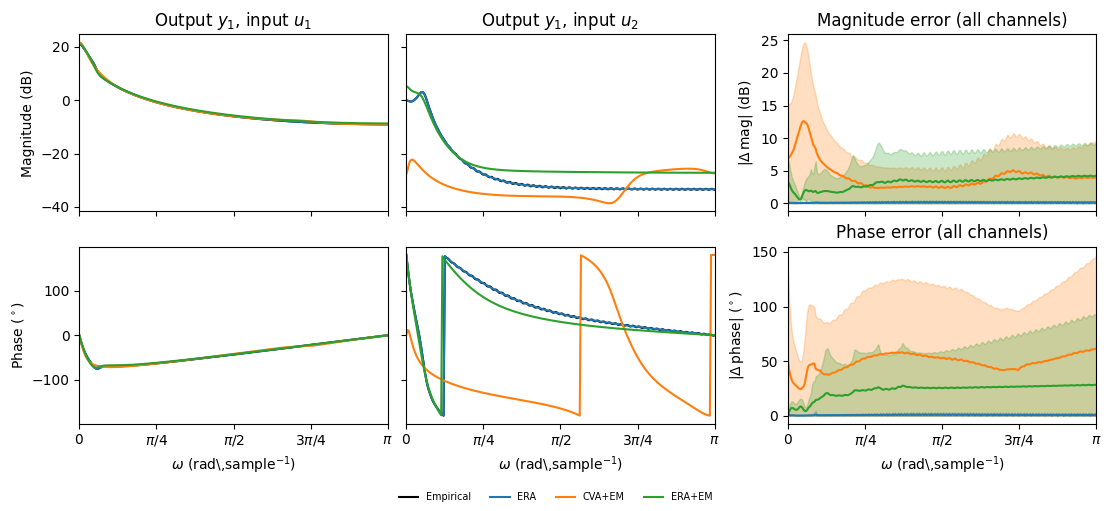

In [5]:
# ── display ────────────────────────────────────────────────────────────────────
configure_screen()
fig = make_bode_figure(freqs, H_emp, model_responses, DISPLAY_OUTPUT, figsize=(11, 5))
plt.show()

In [6]:
# ── pgf export ─────────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC  = 1.0   # fraction of A4 content width
FIG_HEIGHT_FRAC = 0.24  # fraction of A4 content height

configure_pgf()
fig = make_bode_figure(
    freqs, H_emp, model_responses, DISPLAY_OUTPUT,
    figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC),
)
save_pgf(fig, FIGURES_PATH / "bode.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/bode.pgf


In [7]:
# ── caption ────────────────────────────────────────────────────────────────────
n_x   = ESTIMATES[0].A.shape[0]
n_y   = ESTIMATES[0].C.shape[0]
model_names = ", ".join(
    (est.label if i < len(ESTIMATES) - 1 else f"and {est.label}")
    for i, est in enumerate(ESTIMATES)
)

caption = (
    r"Frequency-response comparison for "
    + model_names
    + r" identified models ($n_x = "
    + str(n_x)
    + r"$). "
    r"Left and centre columns: Bode magnitude (top) and phase (bottom) for "
    r"output $y_{"
    + str(DISPLAY_OUTPUT + 1)
    + r"}$ driven by inputs $u_1$ and $u_2$ respectively, comparing the "
    r"empirical response (discrete Fourier transform of "
    + str(N_MARKOV)
    + r" noise-free Markov parameters, zero-padded to "
    + str(N_FFT)
    + r" points) against the analytic response "
    r"$H(\mathrm{e}^{\mathrm{j}\omega}) = C(\mathrm{e}^{\mathrm{j}\omega}I - A)^{-1}B$. "
    r"Right column: absolute magnitude error (top) and absolute phase error (bottom), "
    r"shown as mean $\pm$ 1 s.d.\ across all "
    r"$n_u n_y = "
    + str(n_y * P_DIM)
    + r"$ output--input channels for each model."
)
save_caption(CAPTIONS_PATH / "bode.tex", caption, NOTEBOOK_GITHUB_URL)
print(caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/bode.tex
Frequency-response comparison for ERA, CVA+EM, and ERA+EM identified models ($n_x = 6$). Left and centre columns: Bode magnitude (top) and phase (bottom) for output $y_{1}$ driven by inputs $u_1$ and $u_2$ respectively, comparing the empirical response (discrete Fourier transform of 105 noise-free Markov parameters, zero-padded to 512 points) against the analytic response $H(\mathrm{e}^{\mathrm{j}\omega}) = C(\mathrm{e}^{\mathrm{j}\omega}I - A)^{-1}B$. Right column: absolute magnitude error (top) and absolute phase error (bottom), shown as mean $\pm$ 1 s.d.\ across all $n_u n_y = 32$ output--input channels for each model.
